# Imports

In [5]:
import subprocess
import json
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score,
)

import sys
sys.path.append('..')
from pipeline import (
    RF_FEATURES, SVM_FEATURES, SVM_SCALE_COLS,
    RF_MINMAX_COLS, RF_STANDARD_COLS,
    filter_port, decode_attack_labels, ATTACK_LABELS,
)

# Label dataset

In [3]:
# label_dataset.py will stamp Attack_type onto traffic_log.csv using
# the timestamps written by run_attack.py.
# Output: traffic_log_labeled.csv
result = subprocess.run(
    ['python', 'label_dataset.py'],
    cwd='../services/attacks/',
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

Labeling dataset using attack windows from ../../ryu-controller/run_attack_log.json...
Loaded 7 attack windows from ../../ryu-controller/run_attack_log.json
  SLOWLORIS        start=1776354656.03  end=1776355056.13  duration=400s
  UDP_flood        start=1776355106.14  end=1776355246.25  duration=140s
  ICMP_flood       start=1776358365.35  end=1776358505.45  duration=140s
  SYN_flood        start=1776358555.50  end=1776358695.61  duration=140s
  UDP_flood        start=1776358745.66  end=1776358885.77  duration=140s
  HTTP_flood       start=1776358935.82  end=1776359075.93  duration=140s
  LAND_attack      start=1776359125.99  end=1776359266.10  duration=140s

Processing ../../ryu-controller/traffic_log.csv line-by-line to avoid memory limits...

Labeling results:
  Total rows  : 4107420
  Attack rows : 1527143
  Normal rows : 2580277

Attack type distribution:
SYN_flood       396480
UDP_flood       380310
ICMP_flood      354143
HTTP_flood      323400
LAND_attack     71100
SLOWLORIS   

# Load and Inspect

In [ ]:
# import pandas as pd

chunks = []
for chunk in pd.read_csv('../ryu-controller/traffic_log_labeled.csv', chunksize=100000):
    # keep attack traffic only and drop 'Normal' to save memory immediately
    attack_chunk = chunk[chunk['Traffic'] == 'Attack']
    chunks.append(attack_chunk)

df = pd.concat(chunks, ignore_index=True)

print(df['Attack_type'].value_counts())
print(f'Total attack samples: {len(df)}')

C:\Users\moulo\AppData\Local\Temp\ipykernel_13616\3180791864.py:4: DtypeWarning: Columns (0: Attack_type) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv('../ryu-controller/traffic_log_labeled.csv', chunksize=100000):
C:\Users\moulo\AppData\Local\Temp\ipykernel_13616\3180791864.py:4: DtypeWarning: Columns (0: Attack_type) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv('../ryu-controller/traffic_log_labeled.csv', chunksize=100000):
C:\Users\moulo\AppData\Local\Temp\ipykernel_13616\3180791864.py:4: DtypeWarning: Columns (0: Type_protocole, 1: Attack_type) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv('../ryu-controller/traffic_log_labeled.csv', chunksize=100000):
C:\Users\moulo\AppData\Local\Temp\ipykernel_13616\3180791864.py:4: DtypeWarning: Columns (0: Attack_type) have mixed types. Specify dtype option on import or set low_me

Attack_type
SYN_flood      396480
UDP_flood      380310
ICMP_flood     354143
HTTP_flood     323400
LAND_attack     71100
SLOWLORIS        1710
Name: count, dtype: int64
Total attack samples: 1527143


In [3]:
df.isna().sum()

Timestamp               0
Ip_src                  0
Ip_dst                  0
Same_ip                 0
Port_src                0
Port_dst                0
Ip_protocole            0
Type_protocole    1248348
Icmp                    0
Icmp_code               0
Icmp_type               0
Tcp                     0
Udp                     0
ACK                     0
PSH                     0
RST                     0
SYN                     0
FIN                     0
Http                    0
Ftp                     0
Smtp                    0
Dns                     0
Flow_duration           0
Flow_dur_nsec           0
Packet_count            0
Bytes                   0
Pkt_per_sec             0
Pkt_per_nsec            0
Bytes_per_sec           0
Bytes_per_nsec          0
Traffic                 0
Attack_type             0
dtype: int64

In [8]:
# load run_attack.py process log
with open('../ryu-controller/run_attack_log.json') as f:
    attack_log = json.load(f)

print('CSV timestamp range:')
print(df['Timestamp'].min())
print(df['Timestamp'].max())

print('\nAttack log ranges:')
for entry in attack_log:
    print(f"{entry['attack_type']}: {entry['start']} -> {entry['end']}")

CSV timestamp range:
1776354656.194355
1776359163.623785

Attack log ranges:
SLOWLORIS: 1776354656.0308194 -> 1776355056.1310391
UDP_flood: 1776355106.1399586 -> 1776355246.2452598
ICMP_flood: 1776358365.348265 -> 1776358505.4522178
SYN_flood: 1776358555.50275 -> 1776358695.608606
UDP_flood: 1776358745.662996 -> 1776358885.7711635
HTTP_flood: 1776358935.8222978 -> 1776359075.9340377
LAND_attack: 1776359125.9931247 -> 1776359266.0988705


# Correlation

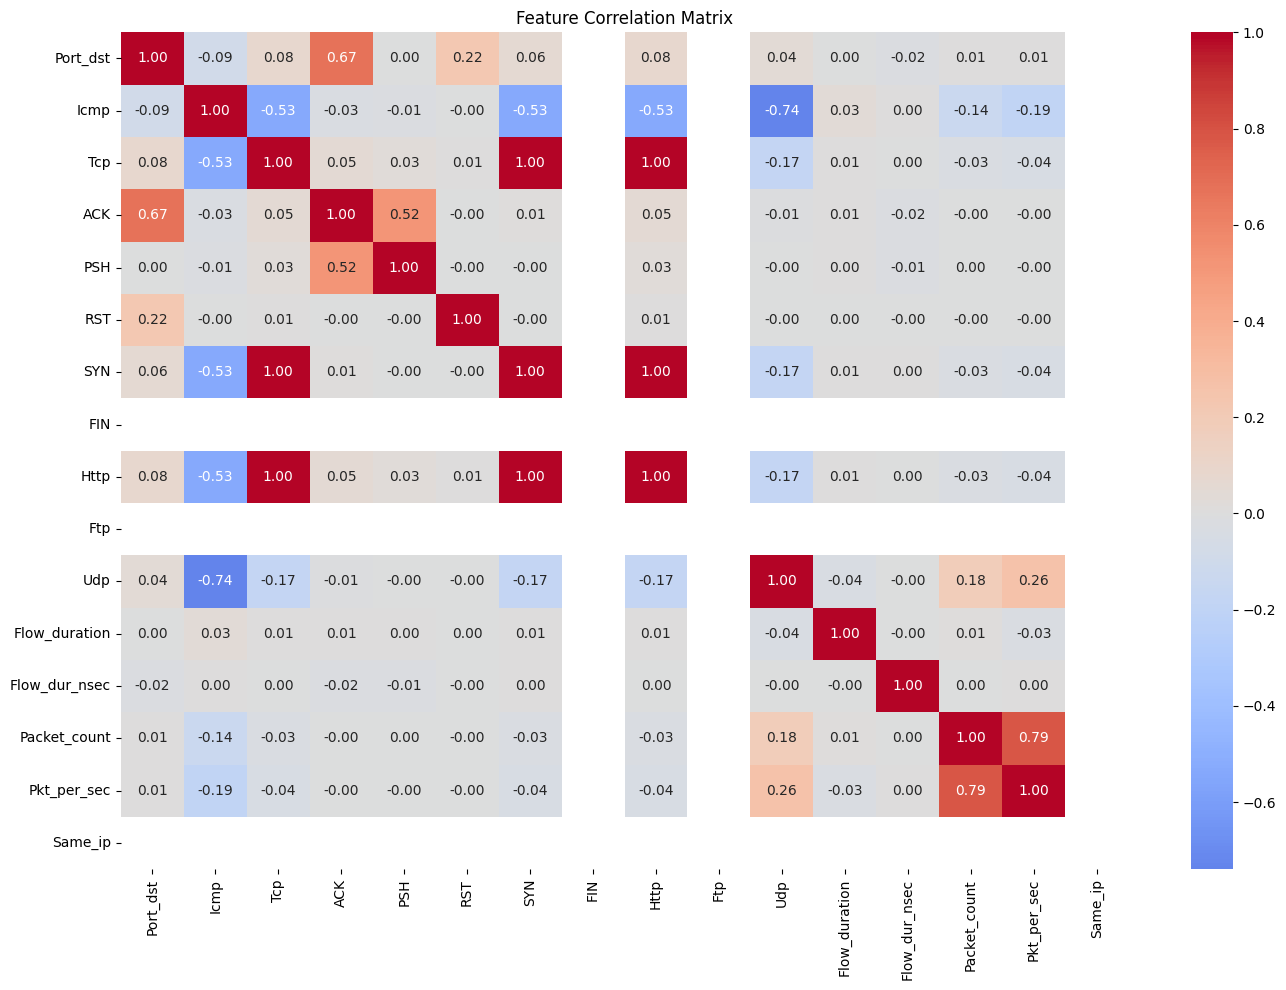

Highly correlated pairs (>0.9):
  Tcp <-> SYN: 0.999
  Tcp <-> Http: 1.000
  SYN <-> Http: 0.999


In [6]:
numeric_cols = RF_FEATURES

plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# highly correlated pairs (threshold 0.9)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print('Highly correlated pairs (>0.9):')
for a, b, v in high_corr:
    print(f'  {a} <-> {b}: {v:.3f}')

# Drop redundant features based on correlation

In [4]:
import sys
sys.path.append('..')
from pipeline import RF_FEATURES

COLS_TO_DROP = ['SYN', 'Http']

FINAL_FEATURES = [f for f in RF_FEATURES if f not in COLS_TO_DROP]
print('Final features:', FINAL_FEATURES)

Final features: ['Port_dst', 'Icmp', 'Tcp', 'ACK', 'PSH', 'RST', 'FIN', 'Ftp', 'Udp', 'Flow_duration', 'Flow_dur_nsec', 'Packet_count', 'Pkt_per_sec', 'Same_ip']


# Label encoding and train-test split

Label distribution:
label
4    396480
5    380310
1    354143
3    323400
2     71100
0      1710
Name: count, dtype: int64


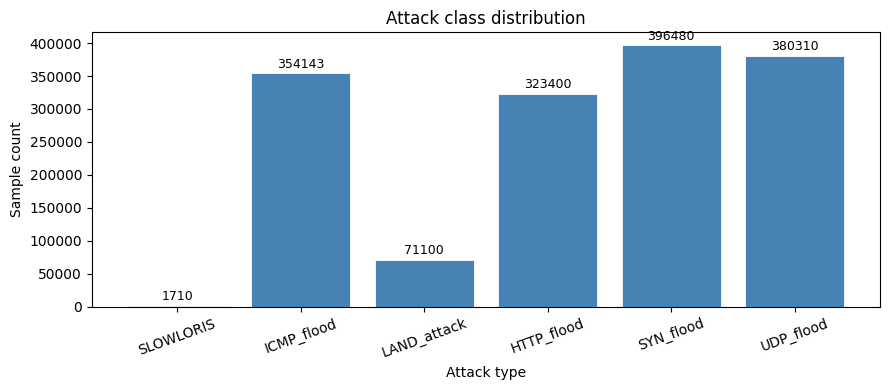

In [8]:
le = LabelEncoder()

# encode attack types to integers matching ATTACK_LABELS
label_map = {v: k for k, v in ATTACK_LABELS.items()}

df['label'] = df['Attack_type'].map(label_map)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

X = df[FINAL_FEATURES].copy()
X['Port_dst'] = X['Port_dst'].apply(filter_port)
y = df['label']

print('Label distribution:')
print(y.value_counts())

# class distribution bar chart
fig, ax = plt.subplots(figsize=(9, 4))
counts = y.value_counts().sort_index()
bars = ax.bar(
    [ATTACK_LABELS[i] for i in counts.index],
    counts.values,
    color='steelblue', edgecolor='white', linewidth=0.6,
)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.01,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=9,
    )
ax.set_title('Attack class distribution')
ax.set_xlabel('Attack type')
ax.set_ylabel('Sample count')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [9]:
print(X.isnull().sum())

Port_dst         0
Icmp             0
Tcp              0
ACK              0
PSH              0
RST              0
FIN              0
Ftp              0
Udp              0
Flow_duration    0
Flow_dur_nsec    0
Packet_count     0
Pkt_per_sec      0
Same_ip          0
dtype: int64


# RF Preprocess

In [9]:
X_rf = X.copy()

mm  = MinMaxScaler()
std = StandardScaler()

# only scale cols that are still present after dropping
mm_cols  = [c for c in RF_MINMAX_COLS  if c in X_rf.columns]
std_cols = [c for c in RF_STANDARD_COLS if c in X_rf.columns]

X_rf[mm_cols]  = mm.fit_transform(X_rf[mm_cols])
X_rf[std_cols] = std.fit_transform(X_rf[std_cols])

# Save original y_train for the second SMOTE to avoid shape mismatch
X_train_rf, X_test_rf, y_train_orig, y_test = train_test_split(
    X_rf, y, test_size=0.2, random_state=42, stratify=y
)

# SVM Preprocess

In [11]:
X_svm = X.copy()

svm_std  = StandardScaler()
svm_cols = [c for c in SVM_SCALE_COLS if c in X_svm.columns]
X_svm[svm_cols] = svm_std.fit_transform(X_svm[svm_cols])

X_train_svm, X_test_svm, y_train_orig_svm, _ = train_test_split(
    X_svm, y, test_size=0.2, random_state=42, stratify=y
)

# Balancing the data with SMOTE

In [10]:
from imblearn.over_sampling import SMOTE

print("Class distribution before SMOTE:")
print(y_train_orig.value_counts().sort_index())

target_counts = {
    0: 20000,  # Slowloris
    2: 100000, # Land attack
}

Class distribution before SMOTE:
label
0      1368
1    283314
2     56880
3    258720
4    317184
5    304248
Name: count, dtype: int64


In [ ]:
smote = SMOTE(sampling_strategy=target_counts, random_state=42)
X_train_rf_bal, y_train_rf_bal = smote.fit_resample(X_train_rf, y_train_orig)

# RF version: X_train_rf is already MinMax+Std scaled from RF Preprocess cell (cell 14),
# so X_train_rf_bal inherits that scaling. Use directly.
X_train_rf = X_train_rf_bal
y_train = y_train_rf_bal

print("\n RF Class distribution after SMOTE:")
print(pd.Series(y_train).value_counts().sort_index())


 RF Class distribution after SMOTE:
label
0     20000
1    283314
2    100000
3    258720
4    317184
5    304248
Name: count, dtype: int64


In [ ]:
# SMOTE on scaled SVM data
smote_svm = SMOTE(sampling_strategy=target_counts, random_state=42)

# Here we use the original unaugmented y_train for the split
X_train_svm_bal, y_train_svm_bal = smote_svm.fit_resample(X_train_svm, y_train_orig_svm)

print("\n SVM Class distribution after SMOTE:")
print(pd.Series(y_train_svm_bal).value_counts().sort_index())


 SVM Class distribution after SMOTE:
label
0     20000
1    283314
2    100000
3    258720
4    317184
5    304248
Name: count, dtype: int64


### This one is for SVC instead of LinearSVC

In [15]:
# 50k samples from SMOTE balanced SVM data
_, X_train_small, _, y_train_small = train_test_split(
    X_train_svm_bal, 
    y_train_svm_bal, 
    test_size=50000,
    stratify=y_train_svm_bal,
    random_state=42
)

print(f"Reduced dataset size: {len(X_train_small)}")
print("Class distribution:")
print(pd.Series(y_train_small).value_counts().sort_index())

Reduced dataset size: 50000
Class distribution:
label
0      779
1    11037
2     3896
3    10079
4    12356
5    11853
Name: count, dtype: int64


# Train RF

In [12]:
# rf = RandomForestClassifier(n_estimators=130, random_state=42, n_jobs=-1) # it was 100 trees before
rf = RandomForestClassifier(
    n_estimators=130,        # optimal from OOB sweep = 130 trees
    max_depth=None,          # let trees grow fully
    min_samples_split=5,     # default 2, increase slightly to reduce overfitting
    min_samples_leaf=2,      # same reasoning
    max_features='sqrt',     # default
    class_weight='balanced', # handles remaining imbalance after SMOTE
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_rf, y_train)
y_pred_rf = rf.predict(X_test_rf)

print('=' * 10)
print('Random Forest')
print('=' * 10)
print(classification_report(y_test, y_pred_rf,
      target_names=list(ATTACK_LABELS.values())))

Random Forest
              precision    recall  f1-score   support

   SLOWLORIS       0.91      0.98      0.94       342
  ICMP_flood       0.72      0.73      0.72     70829
 LAND_attack       0.67      0.93      0.78     14220
  HTTP_flood       0.92      0.85      0.88     64680
   SYN_flood       0.72      0.76      0.74     79296
   UDP_flood       0.85      0.77      0.81     76062

    accuracy                           0.78    305429
   macro avg       0.80      0.84      0.81    305429
weighted avg       0.79      0.78      0.78    305429



d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


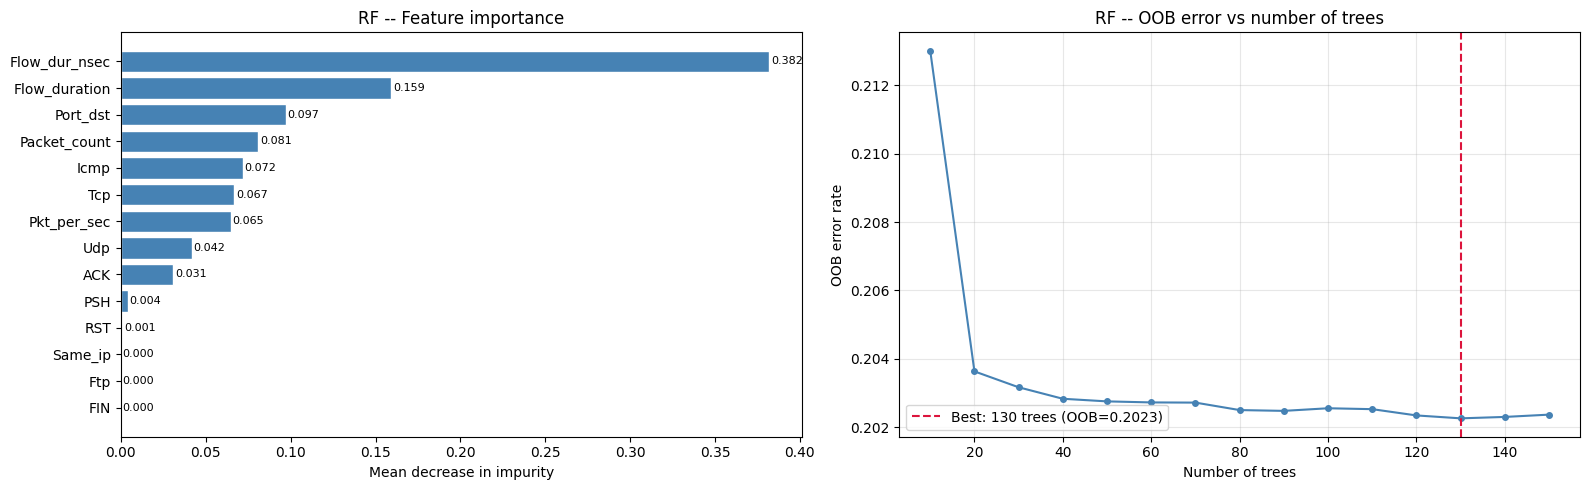

Optimal n_estimators from OOB sweep: 130


In [13]:
# RF: feature importance + OOB error curve

# --- feature importance ---
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
feat_names = [FINAL_FEATURES[i] for i in indices]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(feat_names[::-1], importances[indices][::-1],
             color='steelblue', edgecolor='white')
axes[0].set_title('RF -- Feature importance')
axes[0].set_xlabel('Mean decrease in impurity')
for i, v in enumerate(importances[indices][::-1]):
    axes[0].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

# --- OOB error as a proxy for training convergence (n_estimators sweep) ---
# Trains RF with increasing n_estimators and records OOB error at each step.
# This is the RF equivalent of a loss curve.
rf_oob = RandomForestClassifier(
    warm_start=True, oob_score=True, random_state=42, n_jobs=-1
)
oob_errors = []
estimator_range = range(10, 151, 10)
for n in estimator_range:
    rf_oob.set_params(n_estimators=n)
    rf_oob.fit(X_train_rf, y_train)
    oob_errors.append(1 - rf_oob.oob_score_)

axes[1].plot(list(estimator_range), oob_errors,
             marker='o', markersize=4, color='steelblue', linewidth=1.5)
axes[1].set_title('RF -- OOB error vs number of trees')
axes[1].set_xlabel('Number of trees')
axes[1].set_ylabel('OOB error rate')
axes[1].grid(True, alpha=0.3)

best_n = list(estimator_range)[int(np.argmin(oob_errors))]
axes[1].axvline(best_n, color='crimson', linestyle='--',
                label=f'Best: {best_n} trees (OOB={min(oob_errors):.4f})')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Optimal n_estimators from OOB sweep: {best_n}')

# Train SVM

In [ ]:
from sklearn.svm import LinearSVC

# LinearSVC: trains in O(n) time, proper multiclass, no kernel approximation.
# class_weight='balanced' handles the remaining imbalance after SMOTE.
# CalibratedClassifierCV wraps it to add predict_proba if needed later.

svm_linear = LinearSVC(C=10.0, max_iter=3000, dual='auto', random_state=42)
svm_linear.fit(X_train_svm_bal, y_train_svm_bal)
y_pred_linsvm = svm_linear.predict(X_test_svm)

print('=' * 10)
print('SVM (LinearSVC)')
print('=' * 10)
print(classification_report(y_test, y_pred_linsvm,
      target_names=list(ATTACK_LABELS.values())))

SVM (LinearSVC)
              precision    recall  f1-score   support

   SLOWLORIS       0.88      0.48      0.62       342
  ICMP_flood       0.40      0.40      0.40     70829
 LAND_attack       0.00      0.00      0.00     14220
  HTTP_flood       0.66      0.73      0.69     64680
   SYN_flood       0.39      0.69      0.50     79296
   UDP_flood       0.98      0.29      0.44     76062

    accuracy                           0.50    305429
   macro avg       0.55      0.43      0.44    305429
weighted avg       0.58      0.50      0.48    305429



d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `

d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


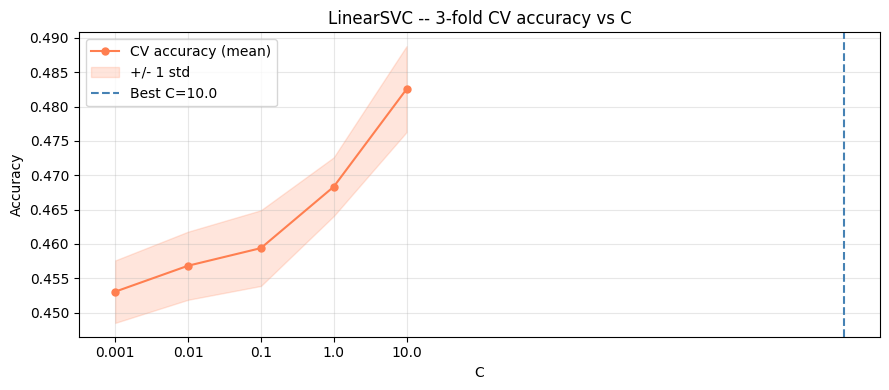

Best C: 10.0  (CV accuracy: 0.4825)


In [ ]:
# LinearSVC C-sweep: same concept as before but actually runs fast now.
C_values = [0.001, 0.01, 0.1, 1.0, 10.0]
cv_means = []
cv_stds  = []

for C in C_values:
    clf = LinearSVC(C=C, max_iter=2000, class_weight='balanced',
                    random_state=42, dual='auto')
    # Using the balanced data. Removed n_jobs=-1 to prevent PicklingError
    # on massive datasets in Windows environments.
    scores = cross_val_score(clf, X_train_svm_bal, y_train_svm_bal,
                             cv=3, scoring='accuracy', n_jobs=1)
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

cv_means = np.array(cv_means)
cv_stds  = np.array(cv_stds)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([str(c) for c in C_values], cv_means,
        marker='o', color='coral', linewidth=1.5, markersize=5,
        label='CV accuracy (mean)')
ax.fill_between(range(len(C_values)),
                cv_means - cv_stds,
                cv_means + cv_stds,
                alpha=0.2, color='coral', label='+/- 1 std')
ax.set_title('LinearSVC -- 3-fold CV accuracy vs C')
ax.set_xlabel('C')
ax.set_ylabel('Accuracy')
ax.grid(True, alpha=0.3)
ax.legend()

best_C = C_values[int(np.argmax(cv_means))]
ax.axvline(best_C, color='steelblue', linestyle='--',
           label=f'Best C={best_C}')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Best C: {best_C}  (CV accuracy: {max(cv_means):.4f})')

### Train SVC on smaller subset, due to big complexity of RBF kernal

In [19]:
svm_rbf = SVC(kernel='rbf', C=1000.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train_small, y_train_small)

y_pred_svm = svm_rbf.predict(X_test_svm)

print('=' * 10)
print('SVM (RBF Kernel on 50k samples)')
print('=' * 10)
print(classification_report(y_test, y_pred_svm,
      target_names=list(ATTACK_LABELS.values())))

SVM (RBF Kernel on 50k samples)
              precision    recall  f1-score   support

   SLOWLORIS       0.84      0.95      0.89       342
  ICMP_flood       0.42      0.36      0.39     70829
 LAND_attack       0.00      0.00      0.00     14220
  HTTP_flood       0.68      0.69      0.69     64680
   SYN_flood       0.38      0.73      0.50     79296
   UDP_flood       0.89      0.32      0.47     76062

    accuracy                           0.50    305429
   macro avg       0.54      0.51      0.49    305429
weighted avg       0.56      0.50      0.48    305429



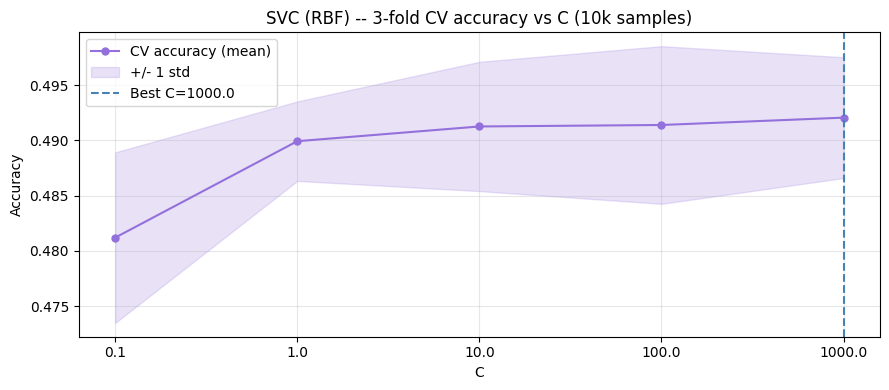

Best C for RBF: 1000.0  (CV accuracy: 0.4921)


In [ ]:
# SVC (RBF kernel) C-sweep on the reduced 10k dataset
C_values_rbf = [0.1, 1.0, 10.0, 100.0, 1000.0]
cv_means_rbf = []
cv_stds_rbf  = []

for C in C_values_rbf:
    clf = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    
    # Using the 10k subset so this finishes in a reasonable time.
    # n_jobs=1 is kept to avoid PicklingError on Windows.
    scores = cross_val_score(clf, X_train_small, y_train_small,
                             cv=3, scoring='accuracy', n_jobs=1)
    cv_means_rbf.append(scores.mean())
    cv_stds_rbf.append(scores.std())

cv_means_rbf = np.array(cv_means_rbf)
cv_stds_rbf  = np.array(cv_stds_rbf)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([str(c) for c in C_values_rbf], cv_means_rbf,
        marker='o', color='mediumpurple', linewidth=1.5, markersize=5,
        label='CV accuracy (mean)')
ax.fill_between(range(len(C_values_rbf)),
                cv_means_rbf - cv_stds_rbf,
                cv_means_rbf + cv_stds_rbf,
                alpha=0.2, color='mediumpurple', label='+/- 1 std')
ax.set_title('SVC (RBF) - 3-fold CV accuracy vs C (10k samples)')
ax.set_xlabel('C')
ax.set_ylabel('Accuracy')
ax.grid(True, alpha=0.3)

best_C_rbf = C_values_rbf[int(np.argmax(cv_means_rbf))]
ax.axvline(str(best_C_rbf), color='steelblue', linestyle='--',
           label=f'Best C={best_C_rbf}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best C for RBF: {best_C_rbf}  (CV accuracy: {max(cv_means_rbf):.4f})')

# Confusion Matrix

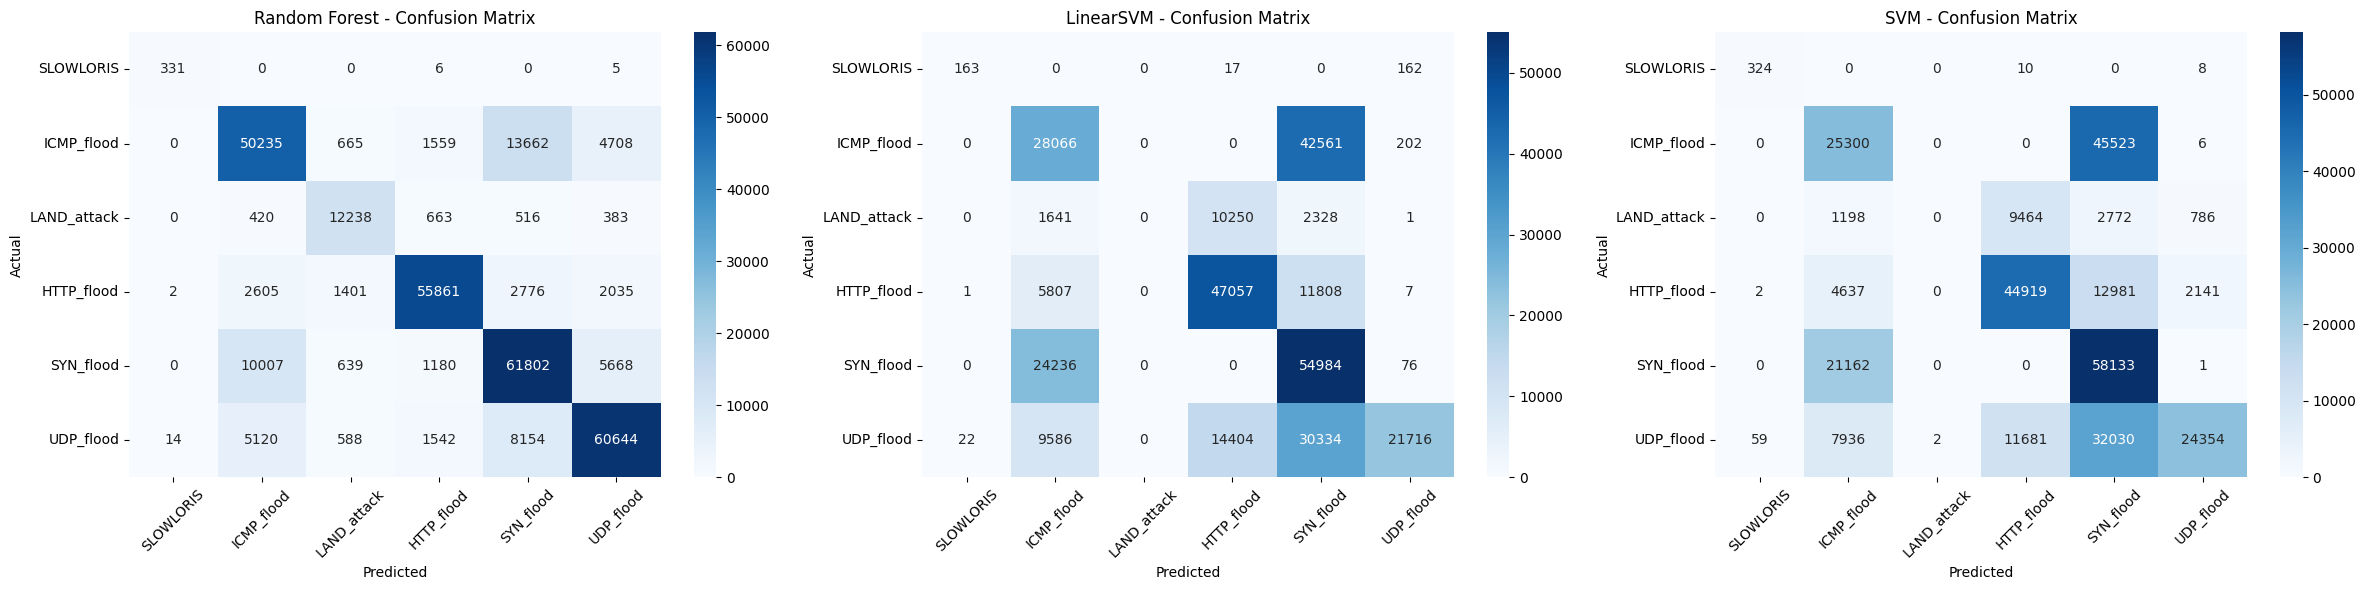

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
labels = list(ATTACK_LABELS.values())

for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_linsvm, y_pred_svm],
    ['Random Forest', 'LinearSVM', 'SVM'],
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels, ax=ax,
    )
    ax.set_title(f'{title} - Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Per-class F1 score comparison between RF, SVM and LinearSVM

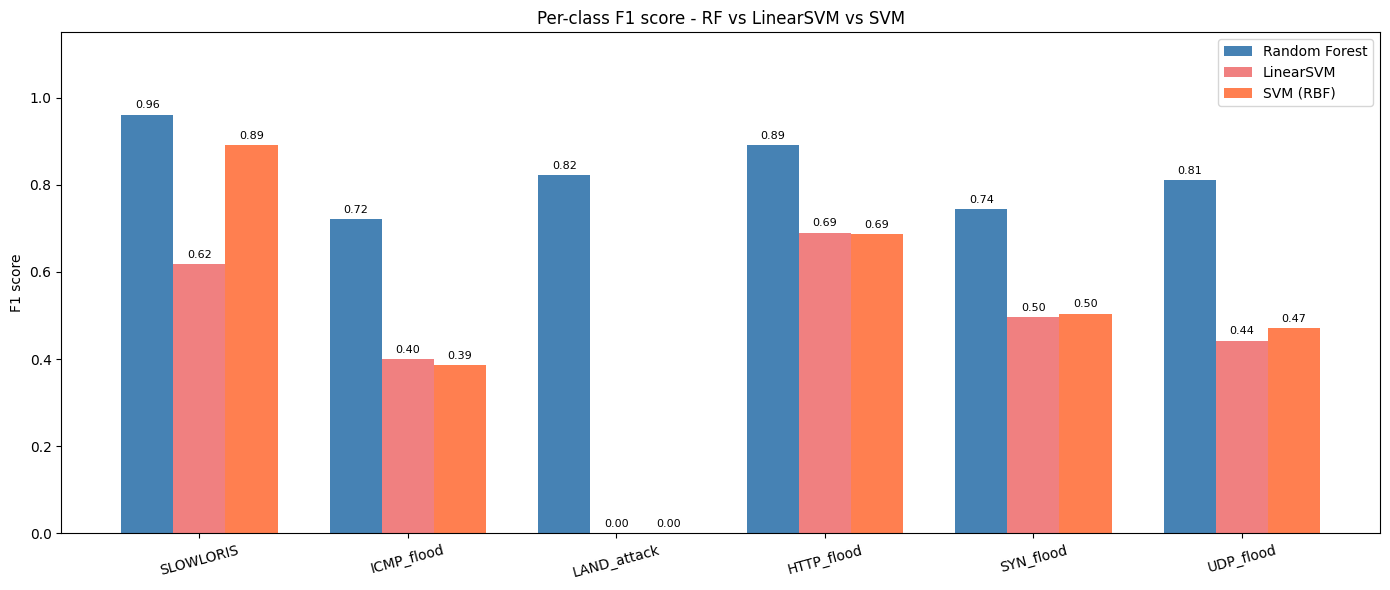

In [24]:
from sklearn.metrics import f1_score

f1_rf  = f1_score(y_test, y_pred_rf,  average=None, labels=list(ATTACK_LABELS.keys()))
f1_linsvm = f1_score(y_test, y_pred_linsvm, average=None, labels=list(ATTACK_LABELS.keys()))
f1_svm = f1_score(y_test, y_pred_svm, average=None, labels=list(ATTACK_LABELS.keys()))

x     = np.arange(len(ATTACK_LABELS))
width = 0.25  # Lowered width to fit 3 bars cleanly

fig, ax = plt.subplots(figsize=(14, 6)) # Increased width
bars_rf  = ax.bar(x - width, f1_rf,  width, label='Random Forest', color='steelblue')
bars_linsvm = ax.bar(x, f1_linsvm, width, label='LinearSVM', color='lightcoral')
bars_svm = ax.bar(x + width, f1_svm, width, label='SVM (RBF)', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(list(ATTACK_LABELS.values()), rotation=15)
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1 score')
ax.set_title('Per-class F1 score - RF vs LinearSVM vs SVM')
ax.legend()

# Fixed combining the 3 sets of bars into one list
for bar in list(bars_rf) + list(bars_linsvm) + list(bars_svm):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.2f}',
        ha='center', va='bottom', fontsize=8,
    )

plt.tight_layout()
plt.show()

# Comparison between RF, SVM and LinearSVM results

d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


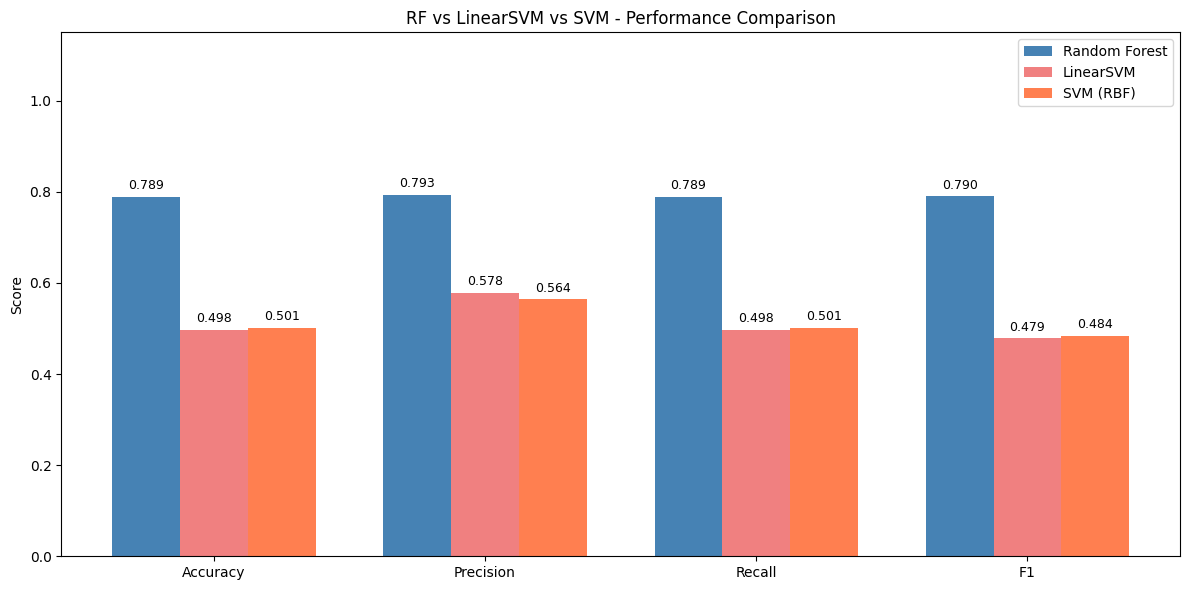

In [25]:
metrics = {
    'Accuracy':  [accuracy_score(y_test, y_pred_rf),
                  accuracy_score(y_test, y_pred_linsvm),
                  accuracy_score(y_test, y_pred_svm)],
    'Precision': [precision_score(y_test, y_pred_rf, average='weighted'),
                  precision_score(y_test, y_pred_linsvm, average='weighted'),
                  precision_score(y_test, y_pred_svm, average='weighted')],
    'Recall':    [recall_score(y_test, y_pred_rf, average='weighted'),
                  recall_score(y_test, y_pred_linsvm, average='weighted'),
                  recall_score(y_test, y_pred_svm, average='weighted')],
    'F1':        [f1_score(y_test, y_pred_rf, average='weighted'),
                  f1_score(y_test, y_pred_linsvm, average='weighted'),
                  f1_score(y_test, y_pred_svm, average='weighted')],
}

x     = np.arange(len(metrics))
width = 0.25 # Lowered width to fit 3 bars cleanly

fig, ax = plt.subplots(figsize=(12, 6)) # Increased width
bars_rf  = ax.bar(x - width, [v[0] for v in metrics.values()],
                  width, label='Random Forest', color='steelblue')
bars_linsvm = ax.bar(x, [v[1] for v in metrics.values()],
                  width, label='LinearSVM', color='lightcoral')
bars_svm = ax.bar(x + width, [v[2] for v in metrics.values()],
                  width, label='SVM (RBF)', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('RF vs LinearSVM vs SVM - Performance Comparison')
ax.legend()

# Consolidated labels loop
for bar in list(bars_rf) + list(bars_linsvm) + list(bars_svm):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Save models

In [ ]:
with open('../ryu-controller/RF.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('../ryu-controller/LinearSVM.pkl', 'wb') as f:
    pickle.dump(svm_linear, f)

with open('../ryu-controller/SVM_RBF.pkl', 'wb') as f:
    pickle.dump(svm_rbf, f)

print('Models saved.')
print(f'\nRF  accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'LinearSVM accuracy: {accuracy_score(y_test, y_pred_linsvm):.4f}')
print(f'SVM RBF accuracy: {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'\nBetter model: {"RF" if accuracy_score(y_test, y_pred_rf) > accuracy_score(y_test, y_pred_linsvm) and accuracy_score(y_test, y_pred_rf) > accuracy_score(y_test, y_pred_svm) else "LinearSVM" if accuracy_score(y_test, y_pred_linsvm) > accuracy_score(y_test, y_pred_svm) else "SVM_RBF"}')

### Saving the models as `onnx` files for compatibility with RYU on python 3.8

In [ ]:
import pickle
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

n_features   = len(FINAL_FEATURES)
initial_type = [('float_input', FloatTensorType([None, n_features]))]

> Comment the pickle loading block if you want to save the models directly after training. I loaded them to save thema after closing the notbook, and to minimize memory usage while doing that.

In [ ]:
with open('../ryu-controller/RF.pkl', 'rb') as f:
    rf = pickle.load(f)

rf_onnx = convert_sklearn(
    rf, 
    initial_types=initial_type, 
    target_opset=11, 
    options={id(rf): {'zipmap': False}}
)
with open('../ryu-controller/RF.onnx', 'wb') as f:
    f.write(rf_onnx.SerializeToString())

print('RF.onnx saved.')

In [3]:
with open('../ryu-controller/LinearSVM.pkl', 'rb') as f:
    svm_linear = pickle.load(f)

linsvm_onnx = convert_sklearn(svm_linear, initial_types=initial_type)
with open('../ryu-controller/LinearSVM.onnx', 'wb') as f:
    f.write(linsvm_onnx.SerializeToString())

print('LinearSVM.onnx saved.')

LinearSVM.onnx saved.


In [4]:
with open('../ryu-controller/SVM_RBF.pkl', 'rb') as f:
    svm_rbf = pickle.load(f)

svm_rbf_onnx = convert_sklearn(svm_rbf, initial_types=initial_type)
with open('../ryu-controller/SVM_RBF.onnx', 'wb') as f:
    f.write(svm_rbf_onnx.SerializeToString())

print('SVM_RBF.onnx saved.')

SVM_RBF.onnx saved.
